# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

explained_variance_ratio [0.79916477 0.18990532 0.01092991]
components_ [[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

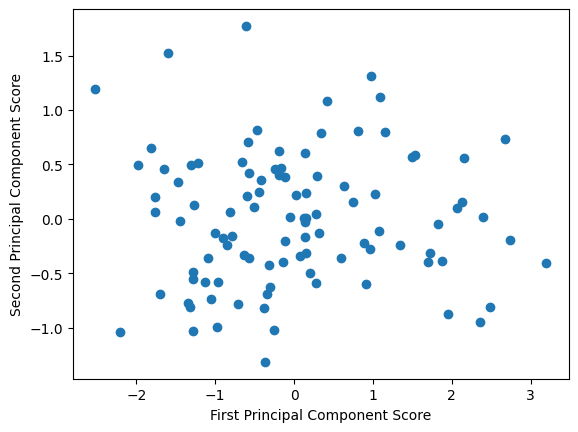

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print("explained_variance_ratio", pca3.explained_variance_ratio_)
print("components_", pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

<Figure size 800x800 with 0 Axes>

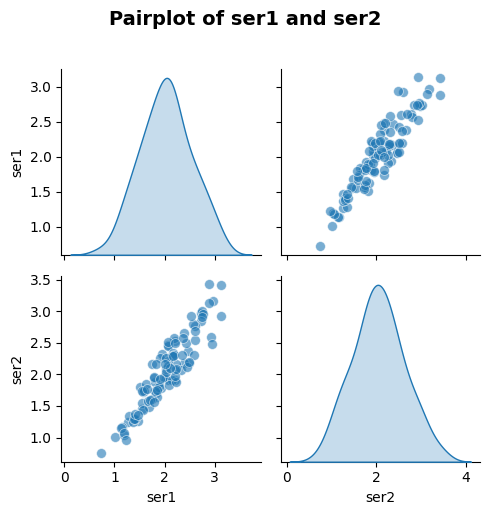

In [6]:
import seaborn as sns

# Create DataFrame
df2 = pd.DataFrame({'ser1': series_1, 'ser2': series_2})

# Create the pairplot
plt.figure(figsize=(8, 8))
sns.pairplot(df2, diag_kind='kde', 
             plot_kws={'alpha': 0.6, 's': 50},
             diag_kws={'fill': True}
             )

plt.suptitle('Pairplot of ser1 and ser2', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

### The Outliers

**First Principal Component Score: LOW**

- Points in the upper left have low, negative values on PC1

**Second Principal Component Score: HIGH**

- Points in the upper left have high, positive values on PC2

**What Can Be Said About Series_3**

- PC1: [0.265, 0.301, 0.916], so Series_3 has the largest value (0.916)
- PC2: [0.603, 0.689, -0.401], so Series_1, Series_2 are positive, Series_3 is negative

- Series_3 values are relatively HIGH compared to series_1 and series_2 for these outliers. Since Series_3 has a loading of 0.916, PC1 is primarily determined by Series_3. When we see a low PC1 score, it means the product is small, which is driven primarily by Series3 being low. Therefore, the outliers have low PC1 because they have low Series_3 values (negative)

**About Series_1 and Series_2:**

- These are hard to Distinguish. Series_1 and series_2 are highly correlated because the correlation is nearly perfect, or almost the same components. PC1 captures the shared variance, making it nearly impossible to separate their individual contributions.

**Advantages of the PCA Plot**

- Outlier: Outliers become immediately visible

- Pattern: Clear separation shows variation exists

**Disadvantages**

- Interpretation: Hard to understand without knowing what PC1/PC2 represent

- Explanatory: Hard to explain to non-technical audiences

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [7]:
# Looad the data from previous weeks
df_clean_99 = pd.read_csv('df_clean_99.csv.zip', compression='zip')
df_final = pd.read_csv('df_final.csv.zip', compression='zip')
df_recent = pd.read_csv('df_recent.csv.zip', compression='zip')


D:\Users\Dustin\AppData\Local\Temp\ipykernel_6756\2302707573.py:2: DtypeWarning: Columns (223,224,225,226,229,307,407,435,463,464,465,466,467,468,469,470,471,486,518,521,522,523,526,527,528,529,535) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean_99 = pd.read_csv('df_clean_99.csv.zip', compression='zip')
D:\Users\Dustin\AppData\Local\Temp\ipykernel_6756\2302707573.py:3: DtypeWarning: Columns (223,224,225,226,229,307,407,435,463,464,465,466,467,468,469,470,471,486,518,521,522,523,526,527,528,529,535) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('df_final.csv.zip', compression='zip')


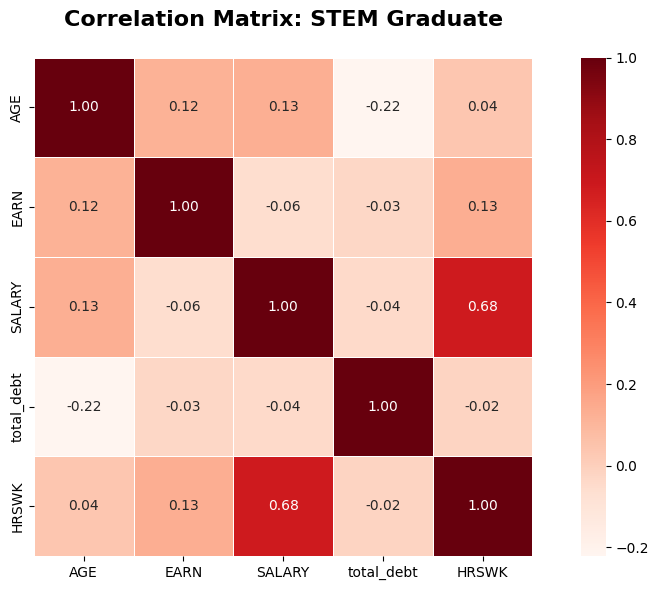

In [8]:
# Select numeric columns for correlation
numeric_cols = ['AGE', 'EARN', 'SALARY', 'total_debt', 'GRLOANR_amount', 'HRSWK']
available_cols = [col for col in numeric_cols if col in df_recent.columns]

# Correlation matrix
corr_matrix = df_recent[available_cols].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Reds', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 1})
plt.title('Correlation Matrix: STEM Graduate\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

I expected to have a strong correlation between SALARY and EARNING, but it showed -0.06. I needed to investigate. As it turned out, I've got the same issue as previous weeks. The SALARY still contains invalid data (99999998) as showed here:

In [9]:
# Check value ranges
print(f"\nEARN range: ${df_recent['EARN'].min():,.0f} - ${df_recent['EARN'].max():,.0f}")
print(f"SALARY range: ${df_recent['SALARY'].min():,.0f} - ${df_recent['SALARY'].max():,.0f}")

# Check if one is full of missing values
print(f"\nEARN missing: {df_recent['EARN'].isna().sum():,} ({df_recent['EARN'].isna().mean()*100:.1f}%)")
print(f"SALARY missing: {df_recent['SALARY'].isna().sum():,} ({df_recent['SALARY'].isna().mean()*100:.1f}%)")

# Check correlation on non-missing values
valid_both = df_recent[df_recent['EARN'].notna() & df_recent['SALARY'].notna()]
print(f"\nValid rows for both: {len(valid_both):,}")
print(f"Correlation on valid rows: {valid_both['EARN'].corr(valid_both['SALARY']):.3f}")



EARN range: $0 - $550,000
SALARY range: $0 - $9,999,998

EARN missing: 0 (0.0%)
SALARY missing: 0 (0.0%)

Valid rows for both: 5,692
Correlation on valid rows: -0.059


In [10]:
# Apply the same cleaning logic to SALARY (as previously done for EARN)

# Remove placeholder values (same as EARN)
invalid_mask = df_recent['SALARY'] >= 9999990
print(f"SALARY values >= 9,999,990: {invalid_mask.sum()}")

# Create cleaned version
df_recent['SALARY_clean'] = df_recent['SALARY'].copy()
df_recent.loc[invalid_mask, 'SALARY_clean'] = np.nan

# Apply top 1% cap (same as EARN)
earnings_99th = df_recent['SALARY_clean'].quantile(0.99)
df_recent['SALARY_capped'] = df_recent['SALARY_clean'].clip(upper=earnings_99th)

# Check value ranges
print(f"\nEARN range: ${df_recent['EARN'].min():,.0f} - ${df_recent['EARN'].max():,.0f}")
print(f"SALARY range: ${df_recent['SALARY_capped'].min():,.0f} - ${df_recent['SALARY_capped'].max():,.0f}")

# Check if one is full of missing values
print(f"\nEARN missing: {df_recent['EARN'].isna().sum():,} ({df_recent['EARN'].isna().mean()*100:.1f}%)")
print(f"SALARY missing: {df_recent['SALARY_capped'].isna().sum():,} ({df_recent['SALARY_capped'].isna().mean()*100:.1f}%)")

# Check correlation on non-missing values
valid_both = df_recent[df_recent['EARN'].notna() & df_recent['SALARY_capped'].notna()]
print(f"\nValid rows for both: {len(valid_both):,}")
print(f"Correlation on valid rows: {valid_both['EARN'].corr(valid_both['SALARY_capped']):.3f}")

SALARY values >= 9,999,990: 210

EARN range: $0 - $550,000
SALARY range: $0 - $400,000

EARN missing: 0 (0.0%)
SALARY missing: 210 (3.7%)

Valid rows for both: 5,482
Correlation on valid rows: 0.857


This is much better. The correlation (0.857) is now much stronger, and the ranges of both EARN and SALARY are more reasonable. 
We can proceed with further analysis using these cleaned versions of the data.

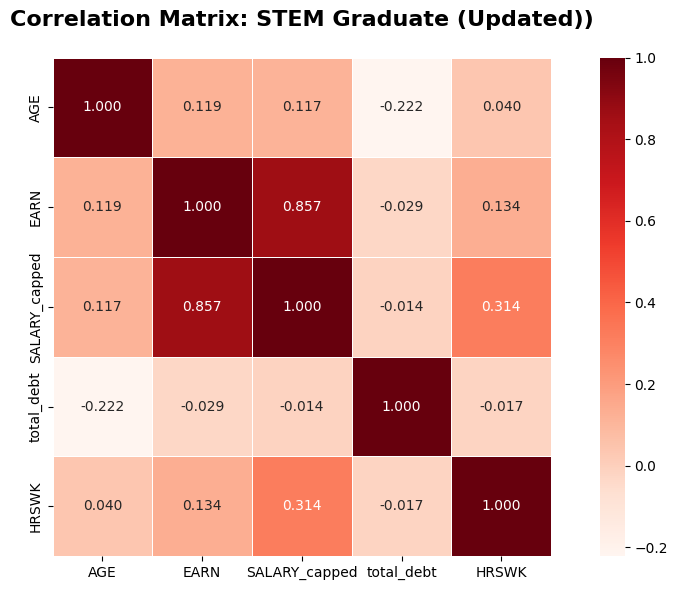

In [11]:
# Update numeric columns with cleaned SALARY
numeric_cols = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']
available_cols = [col for col in numeric_cols if col in df_recent.columns]

# Correlation matrix with cleaned SALARY
corr_matrix = df_recent[available_cols].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='Reds', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: STEM Graduate (Updated))\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### A few observations from the heat map:

1. Data is much more reliable:
   - EARN vs SALARY_capped correlation = 0.857
   - Both income measures are consistent after cleaning

2. Hours vs. Earning:
   - Hours worked correlates with base salary (0.314) 
     but a little weak with total earning (0.134)

3. THE HIDDEN COST FINDING (My Project title):
   - Debt correlates near-zero with both EARN (-0.029) and SALARY_capped (-0.014)
   - This means STEM graduates with higher debt are NOT earning more
   - The hidden cost: debt burden without earnings premium

4. Debt analysis:
   - Age negatively correlated with debt (-0.222)
   - This means younger/recent graduates carry higher debt loads


In [12]:
# Select numeric features for PCA
pca_features = ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']

# Make sure all features exist
available_features = [f for f in pca_features if f in df_recent.columns]
print(f"Features for PCA: {available_features}")

# Drop rows with missing values
pca_data = df_recent[available_features].dropna()
print(f"Rows for PCA: {len(pca_data):,} (dropped {len(df_recent) - len(pca_data)} rows with missing values)")

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

Features for PCA: ['AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK']
Rows for PCA: 5,482 (dropped 210 rows with missing values)


In [13]:
# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\n" + "="*44)
print("PCA EXPLAINED VARIANCE")
print("="*44)

for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i}: {ev:.2%} of variance | Cumulative: {cv:.2%}")

print(f"\nFirst component captures {explained_variance[0]:.2%} of total variance")
print(f"First two components capture {cumulative_variance[1]:.2%} of total variance")


PCA EXPLAINED VARIANCE
PC1: 40.95% of variance | Cumulative: 40.95%
PC2: 24.50% of variance | Cumulative: 65.45%
PC3: 17.24% of variance | Cumulative: 82.69%
PC4: 14.48% of variance | Cumulative: 97.17%
PC5: 2.83% of variance | Cumulative: 100.00%

First component captures 40.95% of total variance
First two components capture 65.45% of total variance


#### Findings:

Using these 5 PCA features: 'AGE', 'EARN', 'SALARY_capped', 'total_debt', 'HRSWK' = Demographic, Total Income, Base Salary, Financial Burden, Working Hours

PC1 represents "Earning" dimension. It captures the income variation

PC2 represents "Age" or the demographic dimension. It captures the age/debt pattern

1. PC1 captures 40.9%: which means the Earnings dimension is important but not dominant
2. PC2 captures 24.5%: Age-debt relationship adds significant information
3. Remaining 34.6% in 3 other components: Hours and other factors still matter

Because `Debt`(financial burden) and `Age` (demographic) don't correlate strongly with `Earnings` (total income), PCA can't collapse everything into one single dimension. This proves that **Total Income** alone don't tell the whole picture.

#### In Summary:

- PCA revealed that STEM graduate outcomes cannot be reduced to a single dimension. 

- The PC1 captures the earnings dimension (dominated by salary and total income), explains only 40.9% of total variance. 
This means Total Income by itself do not tell the complete story of STEM graduate outcomes.

- The PC2 captures demographic/financial burden relationship (dominated by age and debt), explain only 24.5% of variance. 
This confirms a key finding: younger graduates carry higher debt, and this debt burden is largely independent of earnings.

Together, the first two components explain 65.4% of total variance. While this represents a meaningful reduction from 5 original features, the remaining 34.6% of variance distributed across other components suggests that STEM graduate outcomes are multi-dimensional. Each other factors like hours worked, debt burden, and demographic also contribute unique information that cannot be fully captured by earnings alone.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

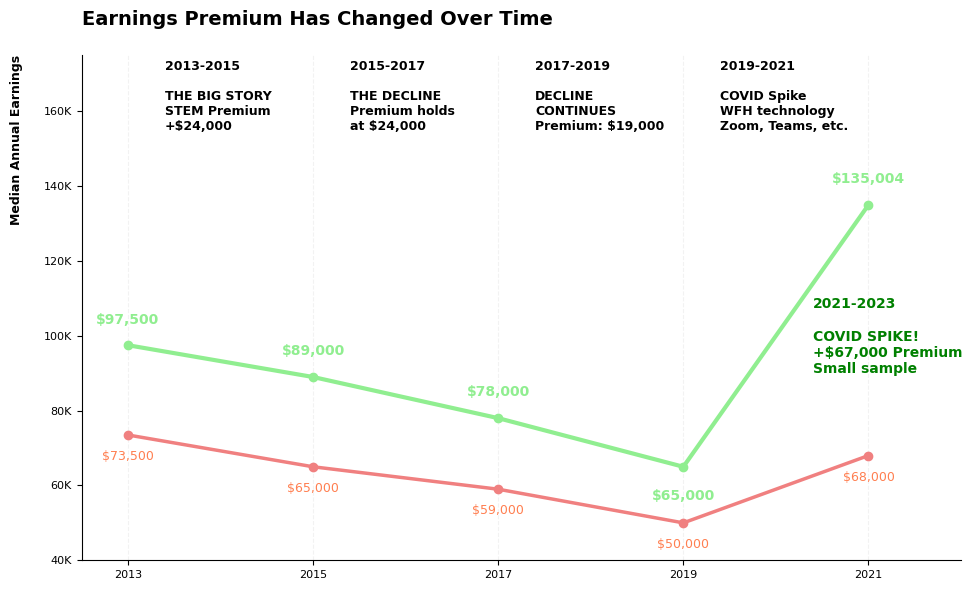

In [14]:
# For this week 9, I choose Figure 9.11 on page 140
# Using my dataset, I will create a similar line chart 
# with annotations at the top to tell the story of how 
# the STEM earnings premium has changed over time.

# Prepare data

cohorts = ['2013', '2015', '2017', '2019', '2021']
stem_earnings = [97500, 89000, 78000, 65000, 135004]
nonstem_earnings = [73500, 65000, 59000, 50000, 68000]
premium = [24000, 24000, 19000, 15000, 67004]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Position for top annotations
top_y = 155000

# Period 1: 2013-15
ax.text(.2, top_y, '2013-2015\n\nTHE BIG STORY\nSTEM Premium\n+$24,000', 
        ha='left', fontsize=9, fontweight='bold')        

# Period 2: 2015-17
ax.text(1.2, top_y, '2015-2017\n\nTHE DECLINE\nPremium holds\nat $24,000', 
        ha='left', fontsize=9, fontweight='bold')

# Period 3: 2017-19
ax.text(2.2, top_y, '2017-2019\n\nDECLINE\nCONTINUES\nPremium: $19,000', 
        ha='left', fontsize=9, fontweight='bold')

# Period 4: 2019-21
ax.text(3.2, top_y, '2019-2021\n\nCOVID Spike\nWFH technology\nZoom, Teams, etc.', 
        ha='left', fontsize=9, fontweight='bold')

# Period 5: 2021-23 (COVID spike)
ax.text(3.7, top_y-65000, '2021-2023\n\nCOVID SPIKE!\n+$67,000 Premium\nSmall sample', 
        ha='left', fontsize=10, fontweight='bold', color='green')

# Plot the lines
ax.plot(cohorts, stem_earnings, 'o-', linewidth=3, markersize=6,
        color='lightgreen', label='STEM Graduates', zorder=3)
ax.plot(cohorts, nonstem_earnings, 'o-', linewidth=2.5, markersize=6,
        color='lightcoral', label='Non-STEM Graduates', zorder=2)


# STEM earnings labels
for i, (cohort, salary) in enumerate(zip(cohorts, stem_earnings)):
    offset = 5000 if i != 3 else -6000  # 2019-21 label below line
    va = 'bottom' if i != 3 else 'top'
    ax.text(i, salary + offset, f'${salary:,.0f}', 
            ha='center', va=va, fontsize=10, fontweight='bold', color='lightgreen')

# Non-STEM earnings labels
for i, (cohort, salary) in enumerate(zip(cohorts, nonstem_earnings)):
    ax.text(i, salary - 4000, f'${salary:,.0f}', 
            ha='center', va='top', fontsize=9, color='coral')

# ===== FORMATTING =====

# xy-axis ticks
def thousands_formatter(x, p):
    return f'{x/1000:.0f}K'

ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
plt.tick_params(axis='x', bottom=True, top=False)
plt.tick_params(axis='y', left=True, right=False)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

# Labels and title
ax.set_ylabel('Median Annual Earnings\n', fontsize=9, fontweight='bold', loc='top')
ax.set_title('Earnings Premium Has Changed Over Time\n', 
             fontsize=14, fontweight='bold', loc='left')

# Set y-axis limits (give room for top annotations)
ax.set_ylim(40000, 175000)
ax.set_xlim(-0.25, 4.5)

# Clean up spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add only vertical grid lines (x-axis)
ax.grid(False) 
ax.xaxis.grid(True, alpha=0.1, linestyle='--', color='gray')

plt.tight_layout()
plt.show()